In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
import pandas as pd

In [3]:
df_dip = pd.read_csv ('/content/Diputaciones.csv', index_col= 'Unnamed: 0')
df_dip.head()

,Aguascalientes,Guanajuato,Jalisco,Michoacán,Querétaro,San Luis Potosí,Zacatecas
1992,8.34,NaN,9.44,NaN,NaN,NaN,NaN
1995,11.94,NaN,8.61,36.32,NaN,NaN,NaN
1997,NaN,16.82,17.97,NaN,14.67,13.59,NaN
1998,10.13,NaN,NaN,36.85,NaN,NaN,42.2
2000,NaN,11.63,12.03,NaN,13.36,13.51,NaN


In [4]:
elecciones_año = list(map(str, range(1992, 2013)))
elecciones_año

['1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012']

In [5]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

In [6]:
print(plt.style.available)
mpl.style.use(['ggplot'])

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


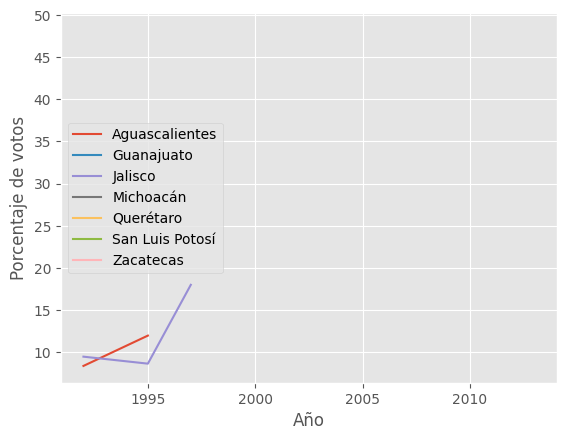

In [7]:
df_dip.plot(kind='line')

plt.ylabel('Porcentaje de votos')
plt.xlabel('Año')

plt.show()

In [10]:
df_dip.index = pd.to_numeric(df_dip.index, errors='coerce')

In [9]:
df_dip_interpolated = df_dip.interpolate(method='linear')

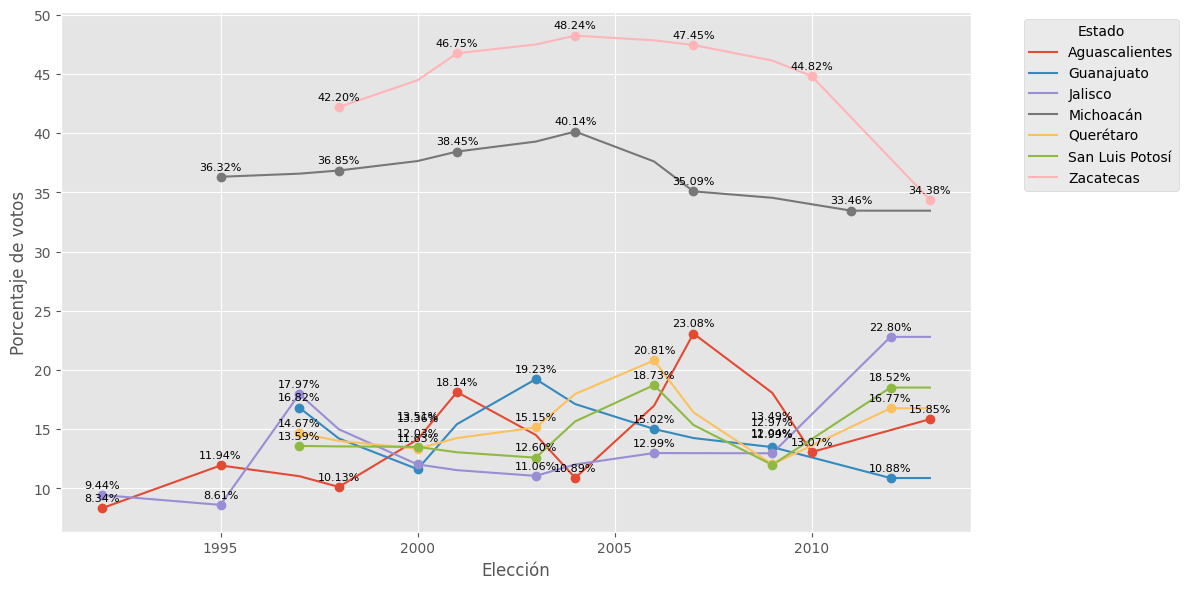

In [13]:
plt.figure(figsize=(12, 6))
ax = df_dip_interpolated.plot(kind='line', linestyle='-', ax=plt.gca())

for column in df_dip.columns:
    ax.plot(df_dip.index, df_dip[column], 'o')

    annotated_positions = []
    for i, y in enumerate(df_dip[column]):
        if not pd.isna(y):
            year = df_dip.index[i]
            x_offset, y_offset = 0, 5

            for (prev_x, prev_y) in annotated_positions:
                if abs(prev_x - year) < 1 and abs(prev_y - y (y + y_offset/100)) < 0.05:
                    y_offset += 15

            if year in [2000, 2009]:
                y_offset += 15


            ax.annotate(f'{y:.2f}%', (year, y), textcoords="offset points", xytext=(x_offset, y_offset), ha='center', fontsize=8)
            annotated_positions.append((year, y + y_offset / 100))

plt.ylabel('Porcentaje de votos')
plt.xlabel('Elección')
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()